# Read XATOM output and convert results into an HDF5 file

This reads XATOM cross section and transition dipole moment calculations and converts them into an HDF5 file.

Produce the XATOM calculations using the following commands after installing XATOM:

```
# do this for every element needed
ELEMENT=Ne
xatom -s $ELEMENT -pcs -PE 0-3000 -dE 1 | sed -e 's/^#[[:space:]]*P.E.(eV)/P.E.(eV)/' > pcs_${ELEMENT}.txt
xatom -s $ELEMENT -pcs -PE 0-3000 -dE 1 -v | sed -e 's/^#[[:space:]]*P.E.(eV)/P.E.(eV)/' > pcs_${ELEMENT}_v.txt
```

Change the following dictionary to select the needed orbitals for the given elements.

In [1]:
import Interpolations
import HDF5
using ReadableRegex
using Format
import Dates
import DelimitedFiles

const eV_per_au = 27.211; # eV

In [2]:
orbitals = Dict(
            #"" => Dict("species"=> "unknown", "n"=>1, "l"=>0, "m"=>0, "Ip"=>870.2, "filename"=>"", "tda"=>"", "orbital"=>"1s"),
            "He1s" => Dict("species"=> "He", "n"=>1, "l"=>0, "m"=>0, "Ip"=>24.6, "filename"=>"pcs_He.txt", "tda"=>"pcs_He_v.txt", "orbital"=>"1s"),
            "Ne1s" => Dict("species"=> "Ne", "n"=>1, "l"=>0, "m"=>0, "Ip"=>870.2, "filename"=>"pcs_Ne.txt", "tda"=>"pcs_Ne_v.txt", "orbital"=>"1s"),
            "N1s" => Dict("species"=> "N", "n"=>1, "l"=>0, "m"=>0, "Ip"=>409.9, "filename"=>"pcs_N.txt", "tda"=>"pcs_N_v.txt", "orbital"=>"1s"),
            "Xe3d" => Dict("species"=> "Xe", "n"=>3, "l"=>2, "m"=>0, "Ip"=>689.0, "filename"=>"pcs_Xe.txt", "tda"=>"pcs_Xe3d_v.txt", "orbital"=>"3d"),
            "C1s" => Dict("species"=> "C", "n"=>1, "l"=>0, "m"=>0, "Ip"=>291.0, "filename"=>"pcs_C.txt", "tda"=>"pcs_C_v.txt", "orbital"=>"1s"),
            "O1s" => Dict("species"=> "O", "n"=>1, "l"=>0, "m"=>0, "Ip"=>537.0, "filename"=>"pcs_O.txt", "tda"=>"pcs_O_v.txt", "orbital"=>"1s"),
            "S1s" => Dict("species"=> "S", "n"=>1, "l"=>0, "m"=>0, "Ip"=>2448.0, "filename"=>"pcs_S.txt", "tda"=>"pcs_S_v.txt", "orbital"=>"1s"),
            "F1s" => Dict("species"=> "F", "n"=>1, "l"=>0, "m"=>0, "Ip"=>688.0, "filename"=>"pcs_F.txt", "tda"=>"pcs_F_v.txt", "orbital"=>"1s"),
            # others, not used so often
            "Kr1s" => Dict("species"=> "Kr", "n"=>1, "l"=>0, "m"=>0, "Ip"=>14.326e3, "filename"=>"pcs_Kr1s.txt", "tda"=>"pcs_Kr1s_v.txt", "orbital"=>"1s"),
            # Xe5p Ip is actually 12.1 eV, but we are assuming multi-photon excitation for a 5 eV laser
            "Xe5p_multi" => Dict("species"=> "Xe", "n"=>5, "l"=>1, "m"=>0, "Ip"=>2.0, "filename"=>"pcs_Xe.txt", "tda"=>"pcs_Xe5p_v.txt", "orbital"=>"5p"),
            # Kr4p Ip is actually 14.1 eV, but we are assuming multi-photon excitation for a 5 eV laser
            "Kr4p_multi" => Dict("species"=> "Kr", "n"=>4, "l"=>1, "m"=>0, "Ip"=>3.2, "filename"=>"pcs_Kr1s.txt", "tda"=>"pcs_Kr1s_v.txt", "orbital"=>"1s"),
            "Xe2p" => Dict("species"=> "Xe", "n"=>2, "l"=>1, "m"=>0, "Ip"=>4776.21, "filename"=>"pcs_Xe2p.txt", "tda"=>"pcs_Xe2p_v.txt", "orbital"=>"2p"),
            "Ar2s" => Dict("species"=> "Ar", "n"=>2, "l"=>0, "m"=>0, "Ip"=>326.0, "filename"=>"pcs_Ar.txt", "tda"=>"pcs_Ar_v.txt", "orbital"=>"2s"),
            #"Xe3d52" => Dict("species"=> "Xe", "n"=>3, "l"=>2, "m"=>0, "Ip"=>676.0, "filename"=>"pcs_Xe.txt", "tda"=>"pcs_Xe3d_v.txt", "orbital"=>"3d"),
           );

In [3]:
function read_tda(filename::String, n::Integer, l::Integer)
    #                       P.E. =  1050.00     n,l -        E,l             R_int
    #                                           1 0 -   192.99 1      -3.13987E-02
    #                                           2 0 -  1006.91 1       6.74669E-03
    #                                           2 1 -  1029.99 0       1.31832E-03
    #                                           2 1 -  1029.99 2       3.18585E-03
    reg_title = look_for(
                           BEGIN * char_in("#") * one_or_more(WHITESPACE) *
                           "P.E." * one_or_more(WHITESPACE) * "=" * one_or_more(WHITESPACE) *
                           ReadableRegex.capture(one_or_more(DEC_DIGIT_NUMBER) * maybe(".") * one_or_more(DEC_DIGIT_NUMBER); as="energy")
                           )
    reg_end = look_for(
                           BEGIN * char_in("#") * maybe(one_or_more(WHITESPACE)) * END
                           )
    reg_data = look_for(
                            BEGIN * char_in("#") * maybe(one_or_more(WHITESPACE)) *
                            ReadableRegex.capture(DEC_DIGIT_NUMBER; as="n") *
                            one_or_more(WHITESPACE) *
                            ReadableRegex.capture(DEC_DIGIT_NUMBER; as="l") *
                            one_or_more(WHITESPACE) * "-" * one_or_more(WHITESPACE) *
                            ReadableRegex.capture(one_or_more(DEC_DIGIT_NUMBER) * maybe(".") * one_or_more(DEC_DIGIT_NUMBER); as="E") *
                            one_or_more(WHITESPACE) *
                            ReadableRegex.capture(DEC_DIGIT_NUMBER; as="tda_l") *
                            one_or_more(WHITESPACE) *
                            ReadableRegex.capture(maybe(either("+", "-")) * one_or_more(DEC_DIGIT_NUMBER) *
                                    maybe(".") * one_or_more(DEC_DIGIT_NUMBER) *
                                    maybe(either("E", "e")) * maybe(either("+", "-")) *
                                    one_or_more(DEC_DIGIT_NUMBER); as="tda")
                        )
    e = Dict()
    tda = Dict()
    tda_int = Dict()
    start_table = false
    start = false
    energy = 0.0
    open(filename) do f
        while !eof(f)
            line = readline(f)
            # ignore initial comments
            if !start_table
                if occursin("# Photoabsorption cross section (in Mb):", line)
                    start_table = true
                end
                # nothing to do so far
                continue
            end
            # if the main data started, process it
            if start_table
                # it has several blocks marked by reg_title
                # check if we found the title so far
                if !start
                    # no title so, check for it
                    m = match(reg_title, line)
                    if m != nothing
                        # title found and we have not seen it so far
                        # get photon energy and mark as the start of section
                        energy = parse(Float64, m["energy"])
                        start = true
                    end
                    # if the title was not found, do nothing
                    # either way, go to the next line, we are done here
                else # a start of block was found previously
                    # check if it ends now
                    m = match(reg_end, line)
                    if m != nothing
                        # it did end, so mark the end of block, and go to the next line
                        start = false
                    else
                        # it did not end, so let's try some actual data!
                        m_data = match(reg_data, line)
                        if m_data != nothing
                            # is it for the orbital we care?
                            found_n, found_l = parse(Int32, m_data["n"]), parse(Int32, m_data["l"])
                            tda_l = parse(Int32, m_data["tda_l"])
                            tda_value = parse(Float64, m_data["tda"])
                            if found_n == n && found_l == l
                                # yes, so save it
                                if tda_l ∉ keys(e)
                                    e[tda_l] = Vector{Float64}()
                                end
                                if tda_l ∉ keys(tda)
                                    tda[tda_l] = Vector{Float64}()
                                end
                                push!(e[tda_l], energy)
                                push!(tda[tda_l], tda_value)
                            end
                        end
                    end
                end
            end
        end
    end
    # interpolate
    tda_int = Dict(p=>Interpolations.linear_interpolation(e[p], tda[p], extrapolation_bc=Interpolations.Line()) for p ∈ keys(tda))
    return tda_int, tda
end

read_tda (generic function with 1 method)

In [4]:
"""Show message `msg` including the current task number."""
function log(msg::AbstractString)
    #println(format("[{1:3d}] {2}", Threads.threadid(), msg))
    #println(format("[{1}] {2}", objectid(current_task()), msg))
    time = Dates.format(Dates.now(), "e, dd u yyyy HH:MM:SS")
    println(format("[{1}] {2}", time, msg))
end

log

In [5]:
"""
Load modules cross section from files in data.
"""
function load_cross_section()
    for name in keys(orbitals)
        if name == ""
            # default for no gas specified
            orbitals[name]["σ"] =  (E -> (E./(E.^3)).^2);
        else
            orbital = orbitals[name]
            current_dir = @__DIR__
            fname = joinpath(current_dir, "..", "data", orbital["filename"])
            log(format("Loading file '{1}' with data for {2}...", fname, name))
            pcs, header = DelimitedFiles.readdlm(fname; header=true, comments=true)
            pe = pcs[:,1];
            σ = pcs[:,findfirst(==(orbital["orbital"]), header)[2]];
            # do linear interpolation, so that we can integrate it later
            fit_σ = Interpolations.linear_interpolation(pe, σ, extrapolation_bc=Interpolations.Line());
            orbitals[name]["cross_section"] = fit_σ;
        end
    end
end

load_cross_section

In [6]:
function load_xatom_tda()

    for name in keys(orbitals)
        if name == ""
            # default for no gas specified
            orbitals[name]["σ"] =  (E -> (E./(E.^3)).^2);
        else
            orbital = orbitals[name]
            current_dir = @__DIR__
            fname = joinpath(current_dir, "..", "data", orbital["tda"])
            log(format("Loading file '{1}' with data for {2}...", fname, name))
            tda_int, tda = read_tda(fname, orbital["n"], orbital["l"])
    
            orbitals[name]["tda_int"] = tda_int
            orbitals[name]["tda_raw"] = tda
            
        end
    end
end


load_xatom_tda (generic function with 1 method)

In [9]:
function dump_results(filename)
    fid = HDF5.h5open(filename, "w")
    e = Array(LinRange(0.0, 3000.0, 3000))
    fid["energy"] = e
    for key in keys(orbitals)
        println("Orbital $(key)")
        grp = HDF5.create_group(fid, key)
        l = orbitals[key]["l"]
        grp["species"] = orbitals[key]["species"]
        grp["orbital"] = orbitals[key]["orbital"]
        grp["n"] = orbitals[key]["n"]
        grp["l"] = orbitals[key]["l"]
        grp["m"] = orbitals[key]["m"]
        grp["Ip"] = orbitals[key]["Ip"]
        tda_grp = HDF5.create_group(grp, "tda")
        tda_keys = collect(keys(orbitals[key]["tda_int"]))
        s = zeros(length(e))
        for target_l in tda_keys
            tda_grp["$(target_l)"] = orbitals[key]["tda_int"][target_l].(e)
            s += orbitals[key]["tda_int"][target_l].(e)
        end
        grp["sum_tda"] = s
        grp["cross_section"] = orbitals[key]["cross_section"].(e)
    end
    close(fid)
end

dump_results (generic function with 1 method)

In [10]:
function get_sample_data(filename::String)
    o = Dict{String, Dict{String, Any}}()
    fid = HDF5.h5open("../data/samples.h5", "r")
    energy = read(fid["energy"])
    for orb in keys(fid)
        if orb == "energy"
            continue
        end
        o[orb] = Dict{String, Any}()
        o[orb]["species"] = read(fid["$(orb)/species"])
        o[orb]["orbital"] = read(fid["$(orb)/orbital"])
        o[orb]["n"] = read(fid["$(orb)/n"])
        o[orb]["l"] = read(fid["$(orb)/l"])
        o[orb]["m"] = read(fid["$(orb)/m"])
        o[orb]["Ip"] = read(fid["$(orb)/Ip"])
        tda = read(fid["$(orb)/sum_tda"])
        cross_section = read(fid["$(orb)/cross_section"])
        o[orb]["tda_int"] = Interpolations.linear_interpolation(energy./eV_per_au, tda, extrapolation_bc=Interpolations.Line());
        o[orb]["cross_section"] = Interpolations.linear_interpolation(energy./eV_per_au, cross_section, extrapolation_bc=Interpolations.Line());
    end
    close(fid)
    return o
end

get_sample_data (generic function with 1 method)

# Read data

In [11]:
load_xatom_tda()
load_cross_section()

[Tue, 15 Sep 2026 13:16:03] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_He_v.txt' with data for He1s...
[Tue, 15 Sep 2026 13:16:03] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_S_v.txt' with data for S1s...
[Tue, 15 Sep 2026 13:16:05] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_Ar_v.txt' with data for Ar2s...
[Tue, 15 Sep 2026 13:16:06] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_C_v.txt' with data for C1s...
[Tue, 15 Sep 2026 13:16:07] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_Xe2p_v.txt' with data for Xe2p...
[Tue, 15 Sep 2026 13:16:16] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_N_v.txt' with data for N1s...
[Tue, 15 Sep 2026 13:16:17] Loading file '/gpfs/exfel/data/scratch/danilo/gh/quacksim/notebooks/../data/pcs_Xe5p_v.txt' with data for Xe5p_multi...
[Tue, 15 Sep 202

# Dump into HDF5 file

In [12]:
dump_results("../data/samples.h5")

Orbital He1s
Orbital S1s
Orbital Ar2s
Orbital C1s
Orbital Xe2p
Orbital N1s
Orbital Xe5p_multi
Orbital O1s
Orbital Xe3d
Orbital Kr4p_multi
Orbital F1s
Orbital Ne1s
Orbital Kr1s


# Test reading

In [15]:
using Plots

In [13]:
o = get_sample_data("../data/samples.h5")

Dict{String, Dict{String, Any}} with 13 entries:
  "N1s"        => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Ne1s"       => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "He1s"       => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "S1s"        => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Ar2s"       => Dict("n"=>2, "m"=>0, "cross_section"=>3000-element extrapolat…
  "C1s"        => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Xe2p"       => Dict("n"=>2, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Xe5p_multi" => Dict("n"=>5, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Kr4p_multi" => Dict("n"=>4, "m"=>0, "cross_section"=>3000-element extrapolat…
  "O1s"        => Dict("n"=>1, "m"=>0, "cross_section"=>3000-element extrapolat…
  "Xe3d"       => Dict("n"=>3, "m"=>0, "cross_section"=>3000-element extrapolat…
  "F1s"        => Dict("n"=>1, "m"=>0, "cross_section"=>3000

In [14]:
o["N1s"]["Ip"]

409.9

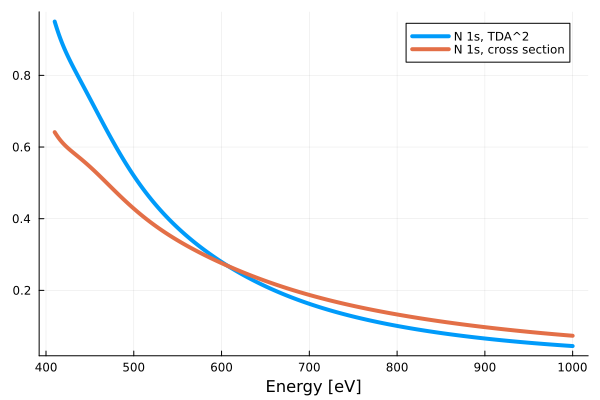

In [16]:
e = Array(LinRange(o["N1s"]["Ip"], 1000.0, 1000))
plot(e, 120*o["N1s"]["tda_int"](e/eV_per_au).^2, linewidth=4, label="N 1s, TDA^2", xlabel="Energy [eV]")
plot!(e, o["N1s"]["cross_section"](e/eV_per_au), linewidth=4, label="N 1s, cross section", xlabel="Energy [eV]")